# Telco Customer Churn Analysis

**Business question:** About one in four customers of a telecom company leaves. *Who* is leaving, *why*, and *how much revenue* does it cost, and where should the retention team focus first?

**Dataset:** IBM Telco Customer Churn sample (7,043 customers, 21 columns), Apache 2.0 licence.
**Tools:** SQL (SQLite) for the business questions, Python (Pandas, Matplotlib) for exploration, scikit-learn for a simple churn-risk model.

*Author: Prijesh Shrestha*

## 1. Load and inspect the data

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
df = pd.read_csv("../data/telco_customer_churn.csv")
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Clean

`TotalCharges` is stored as text and has blank values. Those 11 blanks all belong to customers with `tenure = 0` who haven't been billed yet, so the correct value is 0, not a missing value to drop.

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank = df["TotalCharges"].isna()
print("Blank TotalCharges:", blank.sum(), "| tenure of those rows:", df.loc[blank, "tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["churn_flag"] = (df["Churn"] == "Yes").astype(int)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
print("Missing values left:", int(df.isna().sum().sum()))

Blank TotalCharges: 11 | tenure of those rows: [0]
Duplicate customer IDs: 0
Missing values left: 0


## 3. Business questions in SQL

I load the cleaned table into SQLite and answer the core questions with SQL. The same queries are in `sql/churn_queries.sql`.

In [4]:
con = sqlite3.connect(":memory:")
df.to_sql("customers", con, index=False)

def q(sql):
    return pd.read_sql(sql, con)

q("""
SELECT COUNT(*) AS customers,
       SUM(churn_flag) AS churned,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate_pct,
       ROUND(SUM(CASE WHEN churn_flag = 1 THEN MonthlyCharges END), 0) AS monthly_revenue_lost,
       ROUND(100.0 * SUM(CASE WHEN churn_flag = 1 THEN MonthlyCharges END) / SUM(MonthlyCharges), 1) AS pct_of_monthly_revenue
FROM customers
""")

,customers,churned,churn_rate_pct,monthly_revenue_lost,pct_of_monthly_revenue
0,7043,1869,26.5,139131.0,30.5


**26.5% of customers churned, taking $139k of monthly recurring revenue with them: 30.5% of the total.** Churners pay more per month than customers who stay, so revenue loss is higher than the headcount loss.

In [5]:
q("""
SELECT Contract, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate_pct,
       ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charge
FROM customers GROUP BY Contract ORDER BY churn_rate_pct DESC
""")

,Contract,customers,churn_rate_pct,avg_monthly_charge
0,Month-to-month,3875,42.7,66.40
1,One year,1473,11.3,65.05
2,Two year,1695,2.8,60.77


In [6]:
q("""
SELECT CASE WHEN tenure <= 6 THEN '01: 0-6 months'
            WHEN tenure <= 12 THEN '02: 7-12 months'
            WHEN tenure <= 24 THEN '03: 13-24 months'
            WHEN tenure <= 48 THEN '04: 25-48 months'
            ELSE '05: 49-72 months' END AS tenure_band,
       COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate_pct
FROM customers GROUP BY tenure_band ORDER BY tenure_band
""")

,tenure_band,customers,churn_rate_pct
0,01: 0-6 months,1481,52.9
1,02: 7-12 months,705,35.9
2,03: 13-24 months,1024,28.7
3,04: 25-48 months,1594,20.4
4,05: 49-72 months,2239,9.5


In [7]:
q("""
SELECT PaymentMethod, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate_pct
FROM customers GROUP BY PaymentMethod ORDER BY churn_rate_pct DESC
""")

,PaymentMethod,customers,churn_rate_pct
0,Electronic check,2365,45.3
1,Mailed check,1612,19.1
2,Bank transfer (automatic),1544,16.7
3,Credit card (automatic),1522,15.2


In [8]:
q("""
SELECT InternetService, TechSupport, COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate_pct
FROM customers WHERE InternetService <> 'No'
GROUP BY InternetService, TechSupport ORDER BY InternetService, TechSupport
""")

,InternetService,TechSupport,customers,churn_rate_pct
0,DSL,No,1243,27.8
1,DSL,Yes,1178,9.7
2,Fiber optic,No,2230,49.4
3,Fiber optic,Yes,866,22.6


In [9]:
q("""
SELECT COUNT(*) AS customers,
       ROUND(100.0 * AVG(churn_flag), 1) AS churn_rate_pct,
       ROUND(SUM(MonthlyCharges), 0) AS monthly_revenue
FROM customers
WHERE Contract = 'Month-to-month' AND InternetService = 'Fiber optic'
  AND PaymentMethod = 'Electronic check' AND tenure <= 12
""")

,customers,churn_rate_pct,monthly_revenue
0,631,71.2,51935.0


## 4. Visual exploration

In [10]:
INK, MUTED, BASE, ACCENT, HIGH = "#111c2d", "#5f6c80", "#a9bde8", "#2350b5", "#b67a08"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c9d2de", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 13,
                     "figure.dpi": 110, "savefig.bbox": "tight"})
OVERALL = df["churn_flag"].mean() * 100

def rate_bar(col, order=None, title="", fname=None, ax=None):
    r = df.groupby(col)["churn_flag"].mean().mul(100)
    r = r.reindex(order) if order else r.sort_values(ascending=False)
    ax = ax or plt.subplots(figsize=(7, 3.6))[1]
    colors = [HIGH if v == r.max() else BASE for v in r.values]
    bars = ax.bar(r.index.astype(str), r.values, color=colors, width=0.62)
    ax.axhline(OVERALL, ls="--", lw=1, color=MUTED)
    ax.text(len(r) - 0.5, OVERALL + 1.2, f"overall {OVERALL:.1f}%", ha="right", color=MUTED, fontsize=9)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10, color=INK)
    ax.set_ylabel("Churn rate (%)"); ax.set_title(title, loc="left"); ax.set_ylim(0, r.max() * 1.22)
    if fname: plt.savefig(f"../outputs/{fname}")
    return ax

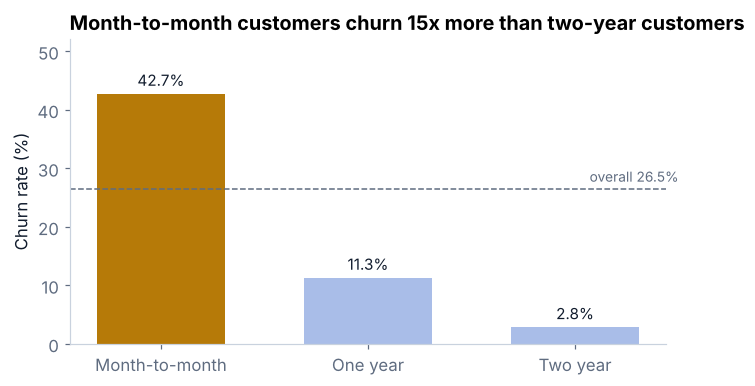

In [11]:
rate_bar("Contract", ["Month-to-month", "One year", "Two year"],
         "Month-to-month customers churn 15x more than two-year customers", "01_churn_by_contract.png")
plt.show()

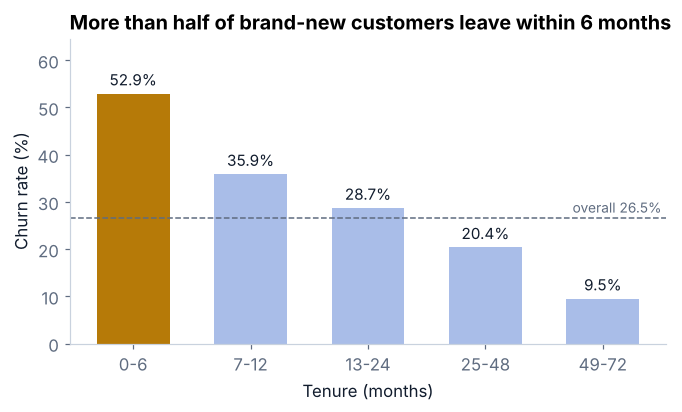

In [12]:
df["tenure_band"] = pd.cut(df["tenure"], [-1, 6, 12, 24, 48, 72],
                           labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
ax = rate_bar("tenure_band", ["0-6", "7-12", "13-24", "25-48", "49-72"],
              "More than half of brand-new customers leave within 6 months")
ax.set_xlabel("Tenure (months)")
plt.savefig("../outputs/02_churn_by_tenure.png"); plt.show()

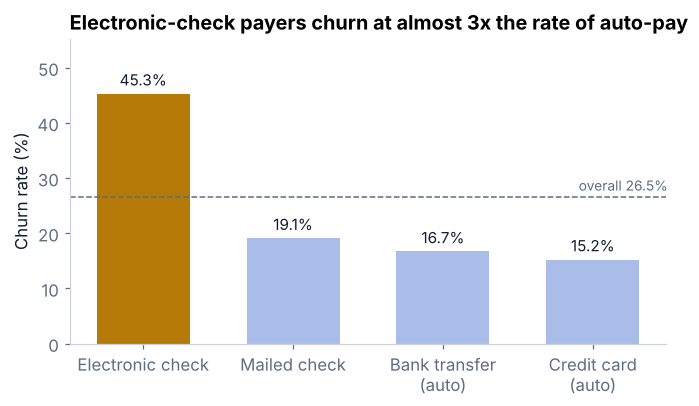

In [13]:
ax = rate_bar("PaymentMethod", None, "Electronic-check payers churn at almost 3x the rate of auto-pay")
ax.set_xticks(range(4)); ax.set_xticklabels([t.get_text().replace(" (automatic)", "\n(auto)") for t in ax.get_xticklabels()])
plt.savefig("../outputs/03_churn_by_payment.png"); plt.show()

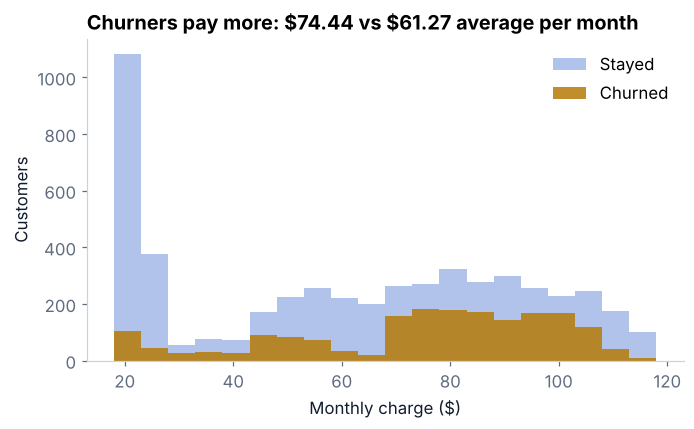

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.arange(18, 122, 5)
ax.hist(df.loc[df.churn_flag == 0, "MonthlyCharges"], bins=bins, color=BASE, label="Stayed", alpha=.9)
ax.hist(df.loc[df.churn_flag == 1, "MonthlyCharges"], bins=bins, color=HIGH, label="Churned", alpha=.85)
ax.set_xlabel("Monthly charge ($)"); ax.set_ylabel("Customers"); ax.legend(frameon=False)
m = df.groupby("Churn")["MonthlyCharges"].mean()
ax.set_title(f"Churners pay more: \${m['Yes']:.2f} vs \${m['No']:.2f} average per month", loc="left")
plt.savefig("../outputs/04_monthly_charges.png"); plt.show()

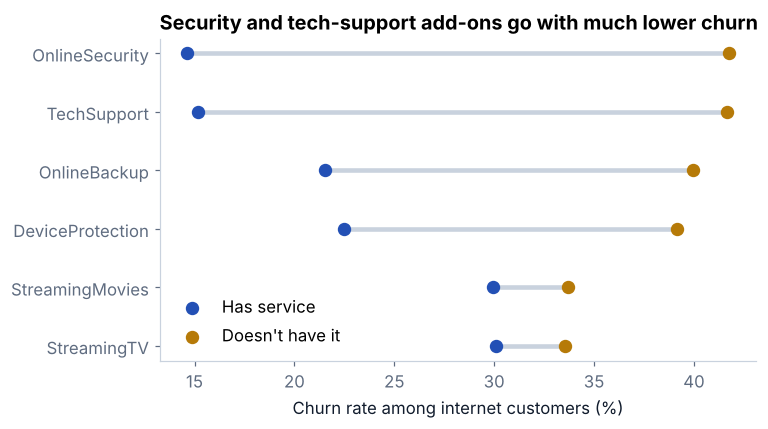

,service,without,with
4,StreamingTV,33.5,30.1
5,StreamingMovies,33.7,29.9
2,DeviceProtection,39.1,22.5
1,OnlineBackup,39.9,21.5
3,TechSupport,41.6,15.2
0,OnlineSecurity,41.8,14.6


In [15]:
addons = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
internet = df[df["InternetService"] != "No"]
rows = []
for a in addons:
    g = internet.groupby(a)["churn_flag"].mean().mul(100)
    rows.append((a, g.get("No"), g.get("Yes")))
addon = pd.DataFrame(rows, columns=["service", "without", "with"]).sort_values("without")
fig, ax = plt.subplots(figsize=(7, 3.8))
y = np.arange(len(addon))
ax.hlines(y, addon["with"], addon["without"], color="#c9d2de", lw=3)
ax.scatter(addon["with"], y, color=ACCENT, s=60, label="Has service", zorder=3)
ax.scatter(addon["without"], y, color=HIGH, s=60, label="Doesn't have it", zorder=3)
ax.set_yticks(y); ax.set_yticklabels(addon["service"])
ax.set_xlabel("Churn rate among internet customers (%)"); ax.legend(frameon=False, loc="lower left")
ax.set_title("Security and tech-support add-ons go with much lower churn", loc="left")
plt.savefig("../outputs/05_addon_services.png"); plt.show()
addon.round(1)

## 5. Churn-risk model

A logistic regression gives each customer a churn probability. I keep the model simple and interpretable: the goal is to rank customers for the retention team, not to squeeze out the last point of accuracy.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

# Charges are dropped to keep coefficients interpretable: TotalCharges is roughly tenure x MonthlyCharges,
# and MonthlyCharges is mostly the sum of the services already in the model.
features = df.drop(columns=["customerID", "Churn", "churn_flag", "tenure_band", "TotalCharges", "MonthlyCharges"])
X = pd.get_dummies(features, drop_first=True, dtype=float)
y = df["churn_flag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler().fit(X_train)
model = LogisticRegression(max_iter=2000).fit(scaler.transform(X_train), y_train)
proba = model.predict_proba(scaler.transform(X_test))[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(classification_report(y_test, (proba >= 0.5).astype(int), digits=3))

Test ROC-AUC: 0.845
              precision    recall  f1-score   support

           0      0.845     0.892     0.868      1294
           1      0.646     0.548     0.593       467

    accuracy                          0.801      1761
   macro avg      0.746     0.720     0.731      1761
weighted avg      0.793     0.801     0.795      1761



Contact top 10% riskiest -> catch 27% of churners (random would catch 10%)
Contact top 20% riskiest -> catch 50% of churners (random would catch 20%)
Contact top 30% riskiest -> catch 67% of churners (random would catch 30%)


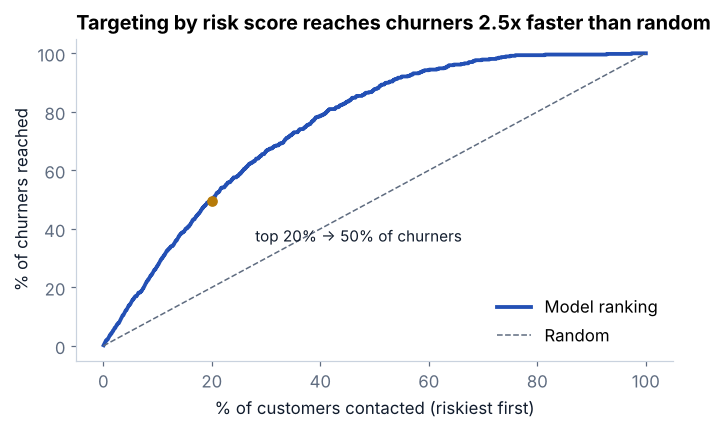

In [17]:
# How useful is the ranking? Share of real churners caught if we contact the riskiest X% first
order = np.argsort(-proba)
caught = np.cumsum(y_test.values[order]) / y_test.sum()
for pct in (10, 20, 30):
    k = int(len(order) * pct / 100)
    print(f"Contact top {pct}% riskiest -> catch {caught[k-1]*100:.0f}% of churners "
          f"(random would catch {pct}%)")

fig, ax = plt.subplots(figsize=(7, 3.8))
share = np.arange(1, len(order) + 1) / len(order) * 100
ax.plot(share, caught * 100, color=ACCENT, lw=2.5, label="Model ranking")
ax.plot([0, 100], [0, 100], ls="--", color=MUTED, lw=1, label="Random")
k20 = int(len(order) * .2)
ax.scatter([20], [caught[k20-1] * 100], color=HIGH, zorder=3)
ax.annotate(f"top 20% -> {caught[k20-1]*100:.0f}% of churners", (20, caught[k20-1] * 100),
            xytext=(28, caught[k20-1] * 100 - 14), color=INK, fontsize=10)
ax.set_xlabel("% of customers contacted (riskiest first)"); ax.set_ylabel("% of churners reached")
ax.set_title("Targeting by risk score reaches churners 2.5x faster than random", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.savefig("../outputs/06_gains_curve.png"); plt.show()

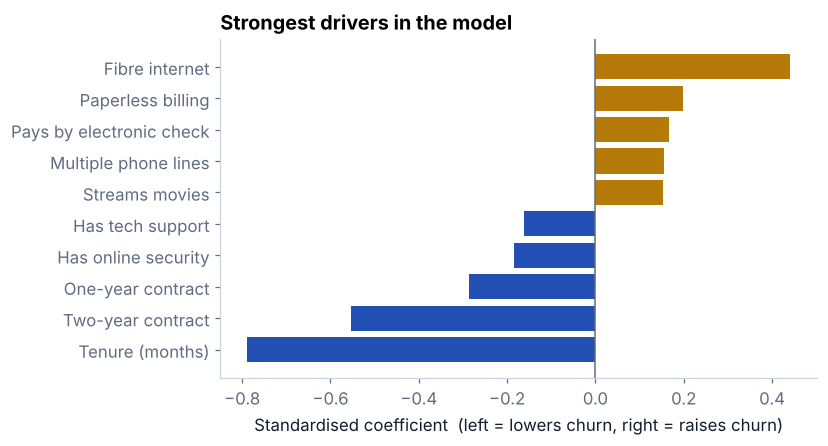

Tenure (months)            -0.79
Two-year contract          -0.55
One-year contract          -0.29
Has online security        -0.18
Has tech support           -0.16
Streams movies              0.15
Multiple phone lines        0.16
Pays by electronic check    0.17
Paperless billing           0.20
Fibre internet              0.44
dtype: float64

In [18]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
top = pd.concat([coef.head(5), coef.tail(5)])
nice = {"tenure": "Tenure (months)", "Contract_Two year": "Two-year contract", "Contract_One year": "One-year contract",
        "OnlineSecurity_Yes": "Has online security", "TechSupport_Yes": "Has tech support",
        "InternetService_Fiber optic": "Fibre internet", "PaperlessBilling_Yes": "Paperless billing",
        "PaymentMethod_Electronic check": "Pays by electronic check", "MultipleLines_Yes": "Multiple phone lines",
        "StreamingMovies_Yes": "Streams movies", "StreamingTV_Yes": "Streams TV"}
top.index = [nice.get(i, i) for i in top.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top.index, top.values, color=[ACCENT if v < 0 else HIGH for v in top.values])
ax.axvline(0, color=MUTED, lw=1)
ax.set_xlabel("Standardised coefficient  (left = lowers churn, right = raises churn)")
ax.set_title("Strongest drivers in the model", loc="left")
plt.savefig("../outputs/07_model_drivers.png"); plt.show()
top.round(2)

## 6. Findings and recommendations

**Highest-risk segment:** 631 customers who are new (12 months or less), on month-to-month contracts, on fibre, and paying by electronic check churn at **71.2%**. They pay $51.9k a month between them, so this is where to start.

| Finding | Evidence | Recommendation |
|---|---|---|
| Churn costs **30.5% of monthly revenue** | 1,869 of 7,043 customers left, taking $139k/month | Treat retention as a revenue problem, not just a customer-count problem |
| **Contract length is the biggest lever** | Month-to-month 42.7% vs two-year 2.8% churn | Offer a discount or perk for moving to a 1-year contract |
| **The first 6 months are critical** | 52.9% churn at 0-6 months vs 9.5% after 4 years | Build an onboarding programme with check-ins in month 1 and 3 |
| **Electronic check is a warning sign** | 45.3% churn vs 15.2-16.7% on auto-pay | Incentivise switching to automatic payment |
| **Add-ons go with loyalty** | Fibre customers: 49.4% churn without tech support vs 22.6% with it | Bundle free Online Security / Tech Support for the first 3 months |
| **Risk scoring focuses effort** | Model (ROC-AUC 0.845): the riskiest 20% of customers contain 50% of churners | Give the retention team a weekly ranked call list |

**Limitations:** this is a single snapshot, so the analysis shows associations rather than proven causes. A/B testing the contract offer would confirm the effect before a full rollout.